In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

sys.path.insert(0, ".")
sys.path.insert(0, "..")   # repo root, for the recovar package
from mseed_predictor import score_file, preprocess_stream, INNER_S

# MiniSEED detection test

Tests `mseed_predictor.py` on a real waveform downloaded from IRIS.

`../data/test.mseed` contains **450 s of KO.DKL..HH?** (Dikili, western Turkey)
centred on the P arrival of the **M6.1 Bigadiç–Balıkesir 2025** earthquake
(2025-08-10T16:53:47 UTC). KO.DKL is ~100 km from the epicentre, placing the
event in the regional distance range where the model's 1–20 Hz band is effective.

The file is committed, so this notebook runs without downloading anything. To
rebuild it from IRIS:
```bash
python create_test_mseed.py
```
or from Python: `from create_test_mseed import fetch_test_mseed; fetch_test_mseed()`.

To use any other MiniSEED file, set `MSEED_PATH` in the configuration cell.


In [2]:
# ============================
# 1. Configuration
# ============================

MSEED_PATH = "../data/test.mseed"
MODEL_PATH = "../models/representation_cross_covariances.h5"
STEP_S     = 10.0    # scoring window step in seconds
THRESHOLD  = 0.5     # detection threshold

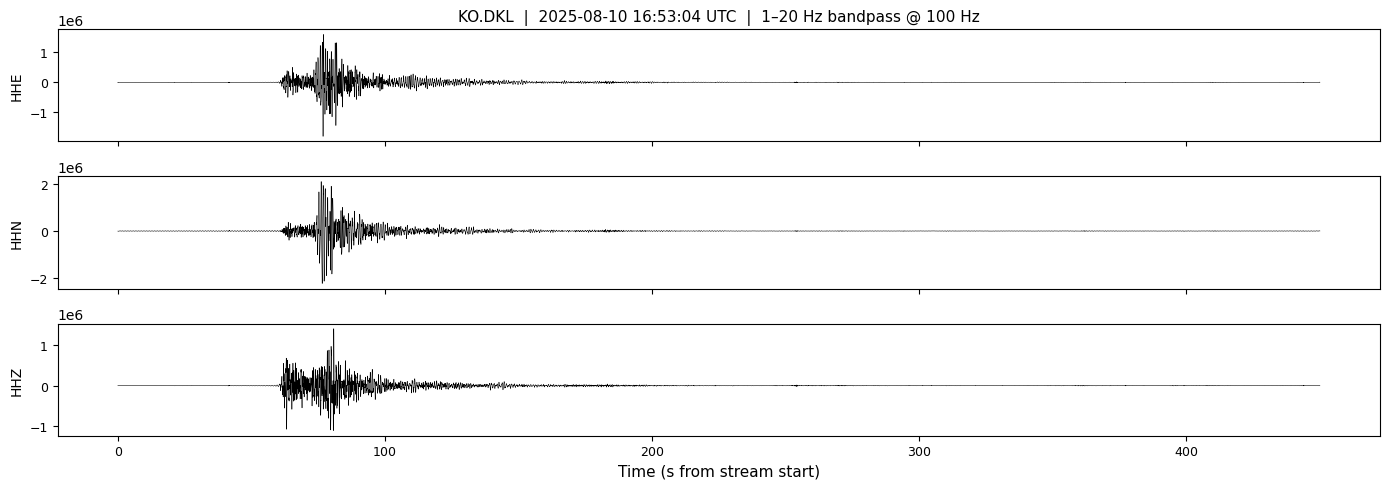

In [3]:
# ============================
# 2. Waveform visualisation (bandpass-filtered, 1–20 Hz @ 100 Hz)
# ============================

st_raw = read(MSEED_PATH)
t0     = st_raw[0].stats.starttime
st     = preprocess_stream(st_raw)   # resample → 1-20 Hz bandpass

fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
for ax, tr in zip(axes, sorted(st, key=lambda t: t.stats.channel)):
    t = np.arange(tr.stats.npts) / tr.stats.sampling_rate
    ax.plot(t, tr.data, "k", linewidth=0.4)
    ax.set_ylabel(tr.stats.channel, fontsize=10)
    ax.tick_params(labelsize=9)

axes[-1].set_xlabel("Time (s from stream start)", fontsize=11)
axes[0].set_title(
    f"{st[0].stats.network}.{st[0].stats.station}  |  "
    f"{t0.strftime('%Y-%m-%d %H:%M:%S')} UTC  |  "
    "1–20 Hz bandpass @ 100 Hz",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [4]:
# ============================
# 3. Score the MiniSEED file
# ============================

results     = list(score_file(MSEED_PATH, MODEL_PATH, step_s=STEP_S))
inner_times = [float(r[1] - t0) for r in results]   # seconds from stream start
scores      = [r[2] for r in results]

print(f"\nScored {len(results)} windows  (step={STEP_S}s, inner window={INNER_S:.0f}s)")
print(f"Score range: {min(scores):.4f} – {max(scores):.4f}")

Loading data/test.mseed ...
Stream spans 2025-08-10T16:53:04.960000Z — 2025-08-10T17:00:34.950000Z
Loading model from models/representation_cross_covariances.h5 ...
2026-06-05 02:48:30.974499: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Model ready. Scoring windows ...



Scored 41 windows  (step=10.0s, inner window=30s)
Score range: 0.0368 – 0.9225


Done. 41 windows total, 0 dropped (gaps), 41 scored.


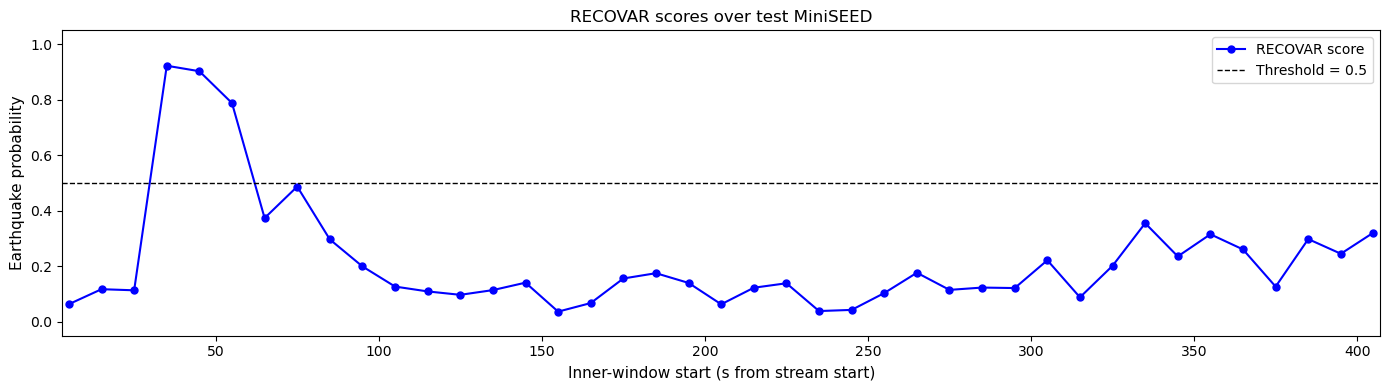

In [5]:
# ============================
# 4. Score plot
# ============================

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(inner_times, scores, "b-o", linewidth=1.5, markersize=5, label="RECOVAR score")
ax.axhline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"Threshold = {THRESHOLD}")

ax.set_xlim(inner_times[0] - 2, inner_times[-1] + 2)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Inner-window start (s from stream start)", fontsize=11)
ax.set_ylabel("Earthquake probability", fontsize=11)
ax.set_title("RECOVAR scores over test MiniSEED", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# ============================
# 5. Detections above threshold
# ============================

detections = [(t, s) for t, s in zip(inner_times, scores) if s >= THRESHOLD]

print(f"Scored {len(results)} windows  (step={STEP_S}s, inner window={INNER_S:.0f}s)")
print(f"Score range : {min(scores):.4f} – {max(scores):.4f}")
print(f"Detections  : {len(detections)} windows above threshold {THRESHOLD}\n")

if detections:
    print(f"  {'inner_start (s)':>16}  {'score':>6}")
    print("  " + "-" * 26)
    for t, s in detections:
        abs_time = t0 + t
        print(f"  {t:>16.1f}  {s:>6.4f}    ({abs_time.strftime('%H:%M:%S')})")

Scored 41 windows  (step=10.0s, inner window=30s)
Score range : 0.0368 – 0.9225
Detections  : 3 windows above threshold 0.5

   inner_start (s)   score
  --------------------------
              35.0  0.9225    (16:53:39)
              45.0  0.9027    (16:53:49)
              55.0  0.7879    (16:53:59)
